
## 1. Chargement des données depuis HDFS

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

'''
- Liste des port -
Jade     : 8020 
Flavien  : 9000
Samuel   :
Aimane   : 
Roissath :9870
'''

port = "9870"
spark = SparkSession.builder.appName("parsing_student_performance").getOrCreate()
df = spark.read.csv(f"hdfs://localhost:{port}/projet/donnees/StudentPerformanceFactors_propre.csv", header=True, inferSchema=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/20 16:48:40 WARN Utils: Your hostname, MacBook-Pro-de-WABI.local, resolves to a loopback address: 127.0.0.1; using 10.213.22.30 instead (on interface en0)
26/07/20 16:48:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).

26/07/20 16:48:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: java.lang.UnsupportedOperationException: getSubject is not supported
	at java.base/javax.security.auth.Subject.getSubject(Subject.java:277)
	at org.apache.hadoop.security.UserGroupInformation.getCurrentUser(UserGroupInformation.java:588)
	at org.apache.spark.util.Utils$.$anonfun$getCurrentUserName$1(Utils.scala:2446)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.util.Utils$.getCurrentUserName(Utils.scala:2446)
	at org.apache.spark.SparkContext.<init>(SparkContext.scala:339)
	at org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:59)
	at java.base/jdk.internal.reflect.DirectConstructorHandleAccessor.newInstance(DirectConstructorHandleAccessor.java:62)
	at java.base/java.lang.reflect.Constructor.newInstanceWithCaller(Constructor.java:499)
	at java.base/java.lang.reflect.Constructor.newInstance(Constructor.java:483)
	at py4j.reflection.MethodInvoker.in

In [1]:
import os
os.environ['JAVA_HOME'] = '/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home'

from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

'''
- Liste des port -
Jade     : 8020 
Flavien  : 9000
Samuel   :
Aimane   : 
Roissath : 9000
'''

port = "9000"
spark = SparkSession.builder.appName("parsing_student_performance").getOrCreate()
df = spark.read.csv(f"hdfs://localhost:{port}/projet/donnees/StudentPerformanceFactors_propre.csv", header=True, inferSchema=True)
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/20 16:48:48 WARN Utils: Your hostname, MacBook-Pro-de-WABI.local, resolves to a loopback address: 127.0.0.1; using 10.213.22.30 instead (on interface en0)
26/07/20 16:48:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/20 16:48:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

## 1.1 Transformation des données

In [2]:
# Mapping des colonnes (Anglais -> Français)
COLUMN_MAPPING = {
    "Hours_Studied": "Heures_Etudiees",
    "Attendance": "Presence",
    "Parental_Involvement": "Implication_Parentale",
    "Access_to_Resources": "Acces_aux_Ressources",
    "Extracurricular_Activities": "Activites_Extrascolaires",
    "Sleep_Hours": "Heures_Sommeil",
    "Previous_Scores": "Scores_Precedents",
    "Motivation_Level": "Niveau_Motivation",
    "Internet_Access": "Acces_Internet",
    "Tutoring_Sessions": "Sessions_Tutorat",
    "Family_Income": "Revenu_Famille",
    "Teacher_Quality": "Qualite_Enseignant",
    "School_Type": "Type_Ecole",
    "Peer_Influence": "Influence_Entourage",
    "Physical_Activity": "Activite_Physique",
    "Learning_Disabilities": "Troubles_Apprentissage",
    "Parental_Education_Level": "Niveau_Education_Parents",
    "Distance_from_Home": "Distance_Maison",
    "Gender": "Genre",
    "Exam_Score": "Score_Examen"
}

# Renommer les colonnes
for old_name, new_name in COLUMN_MAPPING.items():
    if old_name in df.columns:
        df = df.withColumnRenamed(old_name, new_name)

print("Colonnes renommées")

Colonnes renommées


In [3]:
# Traduction des valeurs catégorielles
cols_low_medium_high = ["Implication_Parentale", "Acces_aux_Ressources", "Niveau_Motivation", "Revenu_Famille", "Qualite_Enseignant"]
for c in cols_low_medium_high:
    if c in df.columns:
        df = df.withColumn(c, when(col(c) == "Low", "Bas").when(col(c) == "Medium", "Moyen").when(col(c) == "High", "Haut").otherwise(col(c)))

cols_yes_no = ["Activites_Extrascolaires", "Acces_Internet", "Troubles_Apprentissage"]
for c in cols_yes_no:
    if c in df.columns:
        df = df.withColumn(c, when(col(c) == "Yes", "Oui").when(col(c) == "No", "Non").otherwise(col(c)))

if "Type_Ecole" in df.columns:
    df = df.withColumn("Type_Ecole", when(col("Type_Ecole") == "Public", "Publique").when(col("Type_Ecole") == "Private", "Privee").otherwise(col("Type_Ecole")))

if "Influence_Entourage" in df.columns:
    df = df.withColumn("Influence_Entourage", when(col("Influence_Entourage") == "Negative", "Negative").when(col("Influence_Entourage") == "Neutral", "Neutre").when(col("Influence_Entourage") == "Positive", "Positif").otherwise(col("Influence_Entourage")))

if "Niveau_Education_Parents" in df.columns:
    df = df.withColumn("Niveau_Education_Parents", when(col("Niveau_Education_Parents") == "High School", "Lycee").when(col("Niveau_Education_Parents") == "College", "Licence").when(col("Niveau_Education_Parents") == "Postgraduate", "Master").otherwise(col("Niveau_Education_Parents")))

if "Distance_Maison" in df.columns:
    df = df.withColumn("Distance_Maison", when(col("Distance_Maison") == "Near", "Proche").when(col("Distance_Maison") == "Moderate", "Moderee").when(col("Distance_Maison") == "Far", "Loin").otherwise(col("Distance_Maison")))

if "Genre" in df.columns:
    df = df.withColumn("Genre", when(col("Genre") == "Male", "Homme").when(col("Genre") == "Female", "Femme").otherwise(col("Genre")))

print("Valeurs traduites")

Valeurs traduites


In [4]:
# Nettoyage : suppression des valeurs nulles et doublons
count_before = df.count()
df = df.dropna()
df = df.dropDuplicates()
count_after = df.count()

print(f"Lignes supprimées: {count_before - count_after}")
print(f"Lignes finales: {count_after}")
df.show(5)

Lignes supprimées: 229
Lignes finales: 6378
+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+----------------------+------------------------+---------------+-----+------------+
|Heures_Etudiees|Presence|Implication_Parentale|Acces_aux_Ressources|Activites_Extrascolaires|Heures_Sommeil|Scores_Precedents|Niveau_Motivation|Acces_Internet|Sessions_Tutorat|Revenu_Famille|Qualite_Enseignant|Type_Ecole|Influence_Entourage|Activite_Physique|Troubles_Apprentissage|Niveau_Education_Parents|Distance_Maison|Genre|Score_Examen|
+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+--------

## 2. Encodage des variables catégorielles

In [6]:
df = df.withColumn(
    "Implication_Parentale_num",
    when(df.Implication_Parentale == "Haut", 2)
    .when(df.Implication_Parentale == "Moyen", 1)
    .when(df.Implication_Parentale == "Bas", 0)
)

df = df.withColumn(
    "Influence_Entourage_num",
    when(df.Influence_Entourage == "Negative", -1)
    .when(df.Influence_Entourage == "Positif", 1)
    .when(df.Influence_Entourage == "Neutre", 0)
)

df = df.withColumn(
    "Acces_aux_Ressources_num",
    when(df.Acces_aux_Ressources == "Bas", 0)
    .when(df.Acces_aux_Ressources == "Moyen", 1)
    .when(df.Acces_aux_Ressources == "Haut", 2)
)

df = df.withColumn(
    "Niveau_Motivation_num",
    when(df.Niveau_Motivation == "Bas", 0)
    .when(df.Niveau_Motivation == "Moyen", 1)
    .when(df.Niveau_Motivation == "Haut", 2)
)

df = df.withColumn(
    "Qualite_Enseignant_num",
    when(df.Qualite_Enseignant == "Bas", 0)
    .when(df.Qualite_Enseignant == "Moyen", 1)
    .when(df.Qualite_Enseignant == "Haut", 2)
)

df = df.withColumn(
    "Revenu_Famille_num",
    when(df.Revenu_Famille == "Bas", 0)
    .when(df.Revenu_Famille == "Moyen", 1)
    .when(df.Revenu_Famille == "Haut", 2)
)

df = df.withColumn(
    "Distance_Maison_num",
    when(df.Distance_Maison == "Proche", 0)
    .when(df.Distance_Maison == "Moderee", 1)
    .when(df.Distance_Maison == "Loin", 2)
)

df = df.withColumn(
    "Niveau_Education_Parents_num",
    when(df.Niveau_Education_Parents == "Lycee", 0)
    .when(df.Niveau_Education_Parents == "Licence", 1)
    .when(df.Niveau_Education_Parents == "Master", 2)
)

df = df.withColumn(
    "Activites_Extrascolaires_num",
    when(df.Activites_Extrascolaires == "Oui", 1)
    .when(df.Activites_Extrascolaires == "Non", 0)
)

df = df.withColumn(
    "Troubles_Apprentissage_num",
    when(df.Troubles_Apprentissage == "Oui", 1)
    .when(df.Troubles_Apprentissage == "Non", 0)
)

df = df.withColumn(
    "Acces_Internet_num",
    when(df.Acces_Internet == "Oui", 1)
    .when(df.Acces_Internet == "Non", 0)
)

df = df.withColumn(
    "Type_Ecole_num",
    when(df.Type_Ecole == "Privee", 1)
    .when(df.Type_Ecole == "Publique", 0)
)

df = df.withColumn(
    "Genre_num",
    when(df.Genre == "Femme", 1)
    .when(df.Genre == "Homme", 0)
)

df = df.dropDuplicates()

## 3. Stat - Samuel

### 3.1 Vue d'ensemble

In [ ]:
nb_lignes = df.count()  
print(f"Nombre de lignes  : {nb_lignes}")
print(f"Nombre de colonnes: {len(df.columns)}")

colonnes_numeriques = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
colonnes_categorielles = [c for c in df.columns if c not in colonnes_numeriques]

print("Colonnes numériques   :", colonnes_numeriques)
print("Colonnes catégorielles:", colonnes_categorielles)

### 3.2 Variables numériques 


In [ ]:
agg_exprs = []
for c in colonnes_numeriques:
    agg_exprs += [
        F.count(c).alias(f"{c}__count"),
        F.mean(c).alias(f"{c}__mean"),
        F.stddev(c).alias(f"{c}__stddev"),
        F.variance(c).alias(f"{c}__variance"),
        F.min(c).alias(f"{c}__min"),
        F.max(c).alias(f"{c}__max"),
    ]

resultat = df.agg(*agg_exprs).collect()[0].asDict()

import pandas as pd

lignes = []
for c in colonnes_numeriques:
    lignes.append({
        "Variable": c,
        "Count": resultat[f"{c}__count"],
        "Moyenne": resultat[f"{c}__mean"],
        "Ecart_type": resultat[f"{c}__stddev"],
        "Variance": resultat[f"{c}__variance"],
        "Min": resultat[f"{c}__min"],
        "Max": resultat[f"{c}__max"],
    })

stats_numeriques_pdf = pd.DataFrame(lignes).set_index("Variable").round(3)
stats_numeriques_pdf

### 3.3 Quartiles

In [ ]:
RELATIVE_ERROR = 0.01 
lignes_quantiles = []
conditions_outliers = {}

for c in colonnes_numeriques:
    q1, med, q3 = df.approxQuantile(c, [0.25, 0.5, 0.75], RELATIVE_ERROR)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    lignes_quantiles.append({
        "Variable": c,
        "Q1": q1,
        "Mediane": med,
        "Q3": q3,
        "IQR": iqr,
        "Borne_basse": borne_basse,
        "Borne_haute": borne_haute,
    })
    conditions_outliers[c] = (F.col(c) < borne_basse) | (F.col(c) > borne_haute)

quantiles_pdf = pd.DataFrame(lignes_quantiles).set_index("Variable").round(3)
quantiles_pdf

### 3.4 Variables catégorielles 

In [ ]:
frequences = {}
mode_lignes = []

for c in colonnes_categorielles:
    freq_pdf = df.groupBy(c).count() \
        .withColumn("Pourcentage", F.round(100 * F.col("count") / nb_lignes, 2)) \
        .orderBy(F.col("count").desc()) \
        .toPandas()
    freq_pdf = freq_pdf.rename(columns={c: "Modalite", "count": "Effectif"})
    frequences[c] = freq_pdf

    mode_lignes.append({
        "Variable": c,
        "Mode": freq_pdf.iloc[0]["Modalite"],
        "Effectif_mode": int(freq_pdf.iloc[0]["Effectif"]),
        "Pct_mode": freq_pdf.iloc[0]["Pourcentage"],
        "Nb_modalites": len(freq_pdf),
    })

mode_pdf = pd.DataFrame(mode_lignes).set_index("Variable")
mode_pdf

In [ ]:
# Pour afficher le détail de toutes les variables catégorielles :
for c, freq_pdf in frequences.items():
    print(f"\n--- {c} ---")
    print(freq_pdf.to_string(index=False))

## 4. Identification des features importantes

### 4.1 Clear des lignes contenant des NULL

In [7]:
for i in df.columns:
    i, ":", df.filter(col(i).isNull()).count()

26/07/20 16:54:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


## 4.2 Scoring d'influence des features

In [8]:
colonnes_num = [
    "Heures_Etudiees"
    ,"Presence"
    ,"Heures_Sommeil"
    ,"Scores_Precedents"
    ,"Sessions_Tutorat"
    ,"Activite_Physique"
    ,"Implication_Parentale_num"
    ,"Influence_Entourage_num"
    ,"Acces_aux_Ressources_num"
    ,"Niveau_Motivation_num"
    ,"Qualite_Enseignant_num"
    ,"Revenu_Famille_num"
    ,"Distance_Maison_num"
    ,"Niveau_Education_Parents_num"
    ,"Activites_Extrascolaires_num",
    "Troubles_Apprentissage_num"
    ,"Acces_Internet_num"
    ,"Type_Ecole_num"
    ,"Genre_num"
]

correlations = {}

for c in colonnes_num:
    correlations[c] = df.corr(c, "Score_Examen")

for c, corr in correlations.items():
    print(f"{c} : {round(corr, 4)}")

Heures_Etudiees : 0.4451
Presence : 0.5803
Heures_Sommeil : -0.0172
Scores_Precedents : 0.1743
Sessions_Tutorat : 0.1568
Activite_Physique : 0.0251
Implication_Parentale_num : 0.156
Influence_Entourage_num : 0.0991
Acces_aux_Ressources_num : 0.1679
Niveau_Motivation_num : 0.0885
Qualite_Enseignant_num : 0.0751
Revenu_Famille_num : 0.0946
Distance_Maison_num : -0.0881
Niveau_Education_Parents_num : 0.1053
Activites_Extrascolaires_num : 0.0631
Troubles_Apprentissage_num : -0.0839
Acces_Internet_num : 0.0511
Type_Ecole_num : 0.0109
Genre_num : 0.0049


### Recuperation des features les plus impactantes

In [9]:
sorted_cor = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

top5 = sorted_cor[:5]

print(top5)

[('Presence', 0.5802585402382587), ('Heures_Etudiees', 0.4451041402651174), ('Scores_Precedents', 0.174283049003179), ('Acces_aux_Ressources_num', 0.16785600902892453), ('Sessions_Tutorat', 0.15682926320393245)]


In [10]:
## 3.3 Prediction de score a l'exam en fonction des features importantes

### De Spark a pandas a keras

In [11]:
import numpy as np
import pandas as pd

features = [c for c, _ in top5]
cible = "Score_Examen"

pdf = df.select(features + [cible]).toPandas()
pdf = pdf.dropna()

X = pdf[features].values
y = pdf[cible].values

print(X.shape, y.shape)

(6378, 5) (6378,)


### Split et normalisation

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### PMC Keras

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore

modele = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])

modele.compile(optimizer="adam", loss="mse")

historique = modele.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Entrainement termine")

2026-07-20 16:55:52.395680: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-20 16:55:52.395717: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-20 16:55:52.395722: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-20 16:55:52.395751: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-20 16:55:52.395760: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-20 16:55:53.337744: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Entrainement termine


MSE test  : 4.696


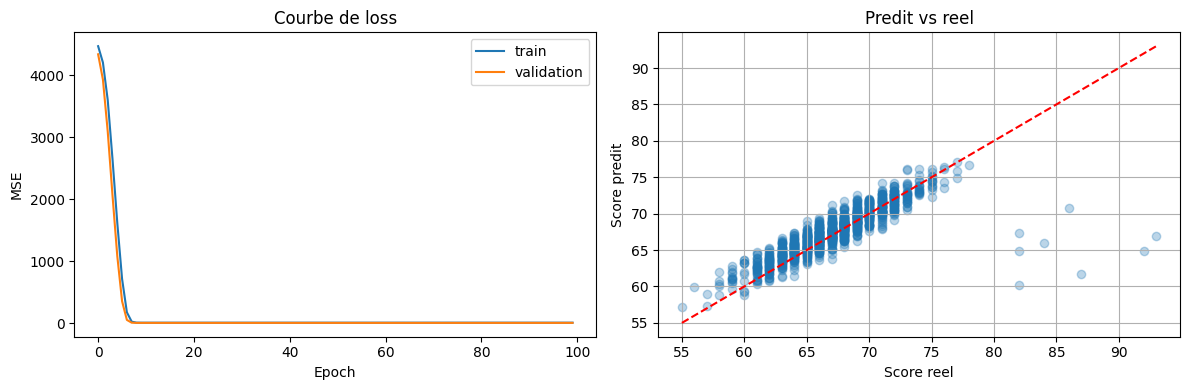

In [14]:
from sklearn.metrics import mean_squared_error

y_pred = modele.predict(X_test, verbose=0).flatten()
mse = mean_squared_error(y_test, y_pred)

print(f"MSE test  : {mse:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe de loss
axes[0].plot(historique.history["loss"], label="train")
axes[0].plot(historique.history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Courbe de loss")
axes[0].legend()

# Predit vs reel
axes[1].scatter(y_test, y_pred, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--")
axes[1].set_xlabel("Score reel")
axes[1].set_ylabel("Score predit")
axes[1].set_title("Predit vs reel")

plt.grid(True)

plt.tight_layout()
plt.show()

### Test sur de nouvelles données

In [15]:
print("Ordre des features :", features)

# Ordre des features :
# [0] Presence                  : % de presence en cours (60-100)
# [1] Heures_Etudiees           : heures d'etude par semaine (0-45)
# [2] Scores_Precedents         : score aux exams precedents (50-100)
# [3] Acces_aux_Ressources_num  : 0=Bas, 1=Moyen, 2=Haut
# [4] Sessions_Tutorat          : nb de sessions de tutorat (0-8)

nouveaux = np.array([
    [95, 30, 85, 2, 5],   # eleve assidu, bien equipe
    [60, 5,  50, 0, 0],   # eleve absent, peu de moyens
    [80, 20, 70, 1, 2],   # profil moyen
])

# Normalisation
nouveaux_scaled = scaler.transform(nouveaux)

predictions = modele.predict(nouveaux_scaled, verbose=0).flatten()

for valeurs, score in zip(nouveaux, predictions):
    print(f"{valeurs} -> score predit : {score:.1f}")

Ordre des features : ['Presence', 'Heures_Etudiees', 'Scores_Precedents', 'Acces_aux_Ressources_num', 'Sessions_Tutorat']
[95 30 85  2  5] -> score predit : 76.8
[60  5 50  0  0] -> score predit : 56.0
[80 20 70  1  2] -> score predit : 67.5
